In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2
import pdb

config = {
    "img_size": 224,
    "patch_size": 16,
    "embed_dim": 768,      # Embedding 通道数
    "depth": 12,           # Vision Transformer 层数
    "num_heads": 12,       # 多头注意力 头数
    "mlp_ratio": 4,        # Vision Transformer的 MLP 膨胀比例 (768 -> 3072)
    "num_classes": 101,    # Food-101 类别数
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"使用设备: {device}")

# 思考: patch_size (14/16/32/etc.) 是越小越好, 还是越大越好?

使用设备: cuda


In [25]:
import os
path = '/root/autodl-tmp/123/ckpt/vit_b_16-imagenet-pretrained.pth'
print(os.path.exists(path))

True


In [26]:
# 数据增强与预处理

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

train_dataset = datasets.Food101(root='/root/autodl-tmp/food-101', split='train', download=False, transform=train_transform)
test_dataset = datasets.Food101(root='/root/autodl-tmp/food-101', split='test', download=False, transform=test_transform)
classes = test_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=10)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=10)


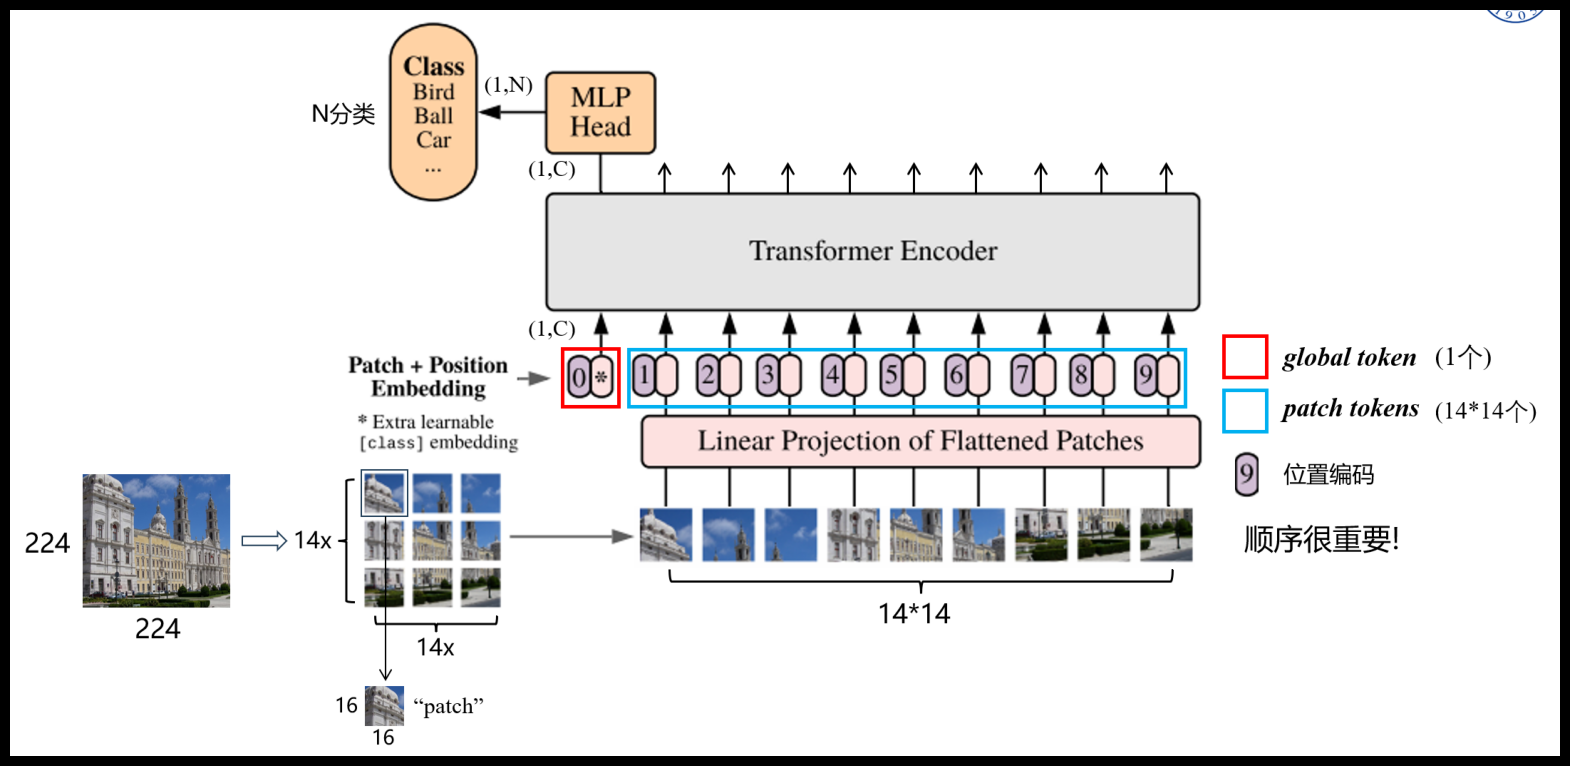

In [27]:
# 打印ViT(Vision Transformer)结构图
plt.figure(figsize=(20, 10))
plt.imshow(Image.open('/root/autodl-tmp/123/architecture/vit.png'))
plt.axis('off')
plt.show()

In [28]:
class ViTBase(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.patch_size = config["patch_size"]
        self.embed_dim = config["embed_dim"]
        
        # Patch Embedding: 使用卷积实现
        self.patch_embed = nn.Conv2d(3, self.embed_dim, kernel_size=self.patch_size, stride=self.patch_size)
        num_patches = (config["img_size"] // self.patch_size) ** 2

        # CLS Token & Positional Embedding 
        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, self.embed_dim))

        # Transformer 骨干网络
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_dim,
            nhead=config["num_heads"],
            dim_feedforward=self.embed_dim * config["mlp_ratio"],
            activation="gelu",
            batch_first=True, # (bs, num_tokens, C): (64, 197, 768)
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config["depth"])

        # 分类头
        self.head = nn.Linear(self.embed_dim, config["num_classes"])
        self.norm = nn.LayerNorm(self.embed_dim)


    def forward(self, x, verbose=False):
        B = x.shape[0]
        # print(f"0. 输入图像 Shape: {x.shape}")

        # Patch Embedding + 拉直
        x = self.patch_embed(x) # [B, 768, 14, 14]
        x = x.flatten(2).transpose(1, 2) # [B, 196, 768]
        # print(f"1. Patch Embedding 后: {x.shape}")

        # 拼接 CLS Token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        # TODO: 如何把cls_tokens和x拼接在一起? (Hint: torch.cat)
        #全局的含义
        x = torch.cat([cls_tokens, x], dim=1)

        # 加上位置编码
        # TODO: 如何把位置编码加到x上? (Hint: 直接相加, 注意维度匹配)
        x = x + self.pos_embed

        # 经过 Transformer Blocks (核心)
        # TODO : 如何把 x 输入到 Transformer 中? (Hint: 直接调用 self.transformer(x))
        self.transformer(x)

        # 提取 CLS Token 输出, 归一化
        x = self.norm(x[:, 0]) # [B, 1, 768]
        # print(f"5. 提取 CLS Token 进行分类的 Shape: {x.shape}")
        
        # 对 CLS Token 进行分类
        # TODO: 如何把 CLS Token 输入到分类头进行分类? (Hint: 直接调用 self.head(x))
        result =self.head(x)
        # 输出返回给result
        
        return result

model = ViTBase(config).to(device)

In [29]:
print("--- 演示：Vision Transformer张量流转过程 ---")
test_img = torch.randn(1, 3, 224, 224).to(device)
_ = model(test_img, verbose=True)

--- 演示：Vision Transformer张量流转过程 ---


In [30]:
# 获取ViT 在 Imagenet 上预训练的权重, 并载入到我们的模型中

# 直接执行即可 (工程需要, 非核心内容)

import torchvision.models as models
def load_imagenet_weights(custom_model):
    print("正在加载 Vision Transformer 的 ImageNet-1K 预训练权重...")
    tv_state = torch.load("/root/autodl-tmp/123/ckpt/vit_b_16-imagenet-pretrained.pth")
    custom_state = custom_model.state_dict()
    new_state = {}
    print("进行参数名称映射...")
    for k_custom in custom_state.keys():
        k_tv = None
        if k_custom == 'cls_token': k_tv = 'class_token'
        elif k_custom == 'pos_embed': k_tv = 'encoder.pos_embedding'
        elif k_custom == 'patch_embed.weight': k_tv = 'conv_proj.weight'
        elif k_custom == 'patch_embed.bias': k_tv = 'conv_proj.bias'
        elif k_custom == 'norm.weight': k_tv = 'encoder.ln.weight'
        elif k_custom == 'norm.bias': k_tv = 'encoder.ln.bias'
        elif 'transformer.layers.' in k_custom:
            parts = k_custom.split('.')
            layer_idx = parts[2]
            suffix = '.'.join(parts[3:])
            if suffix == 'self_attn.in_proj_weight': suffix_tv = 'self_attention.in_proj_weight'
            elif suffix == 'self_attn.in_proj_bias': suffix_tv = 'self_attention.in_proj_bias'
            elif suffix == 'self_attn.out_proj.weight': suffix_tv = 'self_attention.out_proj.weight'
            elif suffix == 'self_attn.out_proj.bias': suffix_tv = 'self_attention.out_proj.bias'
            elif suffix == 'linear1.weight': suffix_tv = 'mlp.linear_1.weight'
            elif suffix == 'linear1.bias': suffix_tv = 'mlp.linear_1.bias'
            elif suffix == 'linear2.weight': suffix_tv = 'mlp.linear_2.weight'
            elif suffix == 'linear2.bias': suffix_tv = 'mlp.linear_2.bias'
            elif suffix == 'norm1.weight': suffix_tv = 'ln_1.weight'
            elif suffix == 'norm1.bias': suffix_tv = 'ln_1.bias'
            elif suffix == 'norm2.weight': suffix_tv = 'ln_2.weight'
            elif suffix == 'norm2.bias': suffix_tv = 'ln_2.bias'
            else: continue
            k_tv = f'encoder.layers.encoder_layer_{layer_idx}.{suffix_tv}'
        if k_custom.startswith('head.'):
            new_state[k_custom] = custom_state[k_custom]
        elif k_tv and k_tv in tv_state:
            new_state[k_custom] = tv_state[k_tv]
        else:
            new_state[k_custom] = custom_state[k_custom]
    custom_model.load_state_dict(new_state)
    print("注入成功！")

load_imagenet_weights(model)

正在加载 Vision Transformer 的 ImageNet-1K 预训练权重...
进行参数名称映射...
注入成功！


In [31]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model):
    size = len(dataloader.dataset)
    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()  
    correct /= size
    print(f"Test Accuracy: {(100*correct):>0.1f}% \n")

In [32]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# 记得要把刚才那些print注释掉!, 否则你会输出一大堆训练细节

# 微调: 由于加载了在ImageNet上的预训练权重，训练时只需要微调5个epoch左右, 就可以达到很不错的效果了
epochs = 5
# 由于课堂时间原因, 减少为1个epoch, 也能看到不错的性能

print("开始训练...")
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, model, loss_fn, optimizer)
    test(test_loader, model)
    
torch.save(model.state_dict(), f'ViT.pth')
print(f"训练完成! 保存到了ViT.pth")

开始训练...
Epoch 1
-------------------------------
loss: 4.609457  [   64/75750]
loss: 4.643194  [ 6464/75750]
loss: 4.610963  [12864/75750]
loss: 4.628049  [19264/75750]
loss: 4.628510  [25664/75750]
loss: 4.622573  [32064/75750]
loss: 4.602816  [38464/75750]
loss: 4.625898  [44864/75750]
loss: 4.617017  [51264/75750]
loss: 4.606809  [57664/75750]
loss: 4.623572  [64064/75750]
loss: 4.622838  [70464/75750]
Test Accuracy: 1.0% 

Epoch 2
-------------------------------
loss: 4.604526  [   64/75750]
loss: 4.639264  [ 6464/75750]
loss: 4.599347  [12864/75750]
loss: 4.610844  [19264/75750]
loss: 4.633491  [25664/75750]
loss: 4.623302  [32064/75750]
loss: 4.618348  [38464/75750]
loss: 4.617518  [44864/75750]
loss: 4.617380  [51264/75750]
loss: 4.608851  [57664/75750]
loss: 4.614669  [64064/75750]
loss: 4.616414  [70464/75750]
Test Accuracy: 1.0% 

Epoch 3
-------------------------------
loss: 4.619521  [   64/75750]
loss: 4.611782  [ 6464/75750]
loss: 4.613998  [12864/75750]
loss: 4.612927  [1

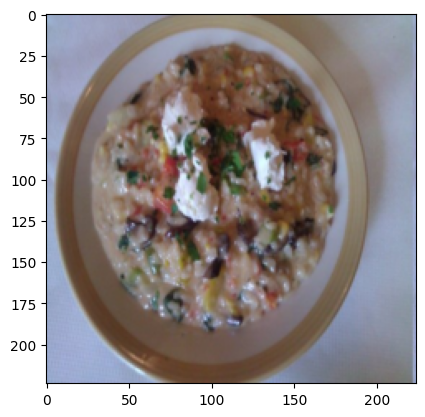

真实标签:  意式烩饭
预测标签:  意式烩饭


In [15]:
# 取样本，作测试
import random

food101_classes = [
    "苹果派", "猪小排", "巴克拉瓦", "生牛肉片", "鞑靼牛肉", 
    "甜菜沙拉", "贝涅饼", "石锅拌饭", "面包布丁", "早餐卷饼", 
    "意式烤面包", "凯撒沙拉", "奶油甜馅煎饼卷", "卡普里沙拉", "胡萝卜蛋糕", 
    "柠檬汁腌鱼", "芝士蛋糕", "奶酪拼盘", "咖喱鸡", "鸡肉法式馅饼", 
    "鸡翅", "巧克力蛋糕", "巧克力慕斯", "吉拿棒", "蛤蜊浓汤", 
    "会所三明治", "蟹肉饼", "法式烤布蕾", "库克太太三明治", "杯子蛋糕", 
    "恶魔蛋", "甜甜圈", "饺子", "毛豆", "班尼迪克蛋", 
    "焗蜗牛", "炸豆丸子", "菲力牛排", "炸鱼薯条", "鹅肝", 
    "薯条", "法式洋葱汤", "法式吐司", "炸鱿鱼", "炒饭", 
    "冷冻酸奶", "大蒜面包", "意式土豆团子", "希腊沙拉", "烤奶酪三明治", 
    "烤三文鱼", "鳄梨酱", "煎饺", "汉堡", "酸辣汤", 
    "热狗", "墨西哥庄园蛋", "鹰嘴豆泥", "冰激凌", "意式肉酱千层面", 
    "龙虾浓汤", "龙虾卷三明治", "奶酪通心粉", "马卡龙", "味噌汤", 
    "贻贝", "墨西哥玉米片", "欧姆蛋", "洋葱圈", "生蚝", 
    "泰式炒河粉", "西班牙海鲜饭", "烤薄饼", "意式奶冻", "北京烤鸭", 
    "越南河粉", "披萨", "猪排", "普丁", "上等牛肋排", 
    "撕扯猪肉三明治", "拉面", "意式馄饨", "红丝绒蛋糕", "意式烩饭", 
    "萨莫萨三角炸饺", "生鱼片", "扇贝", "海藻沙拉", "鲜虾玉米粥", 
    "意式肉酱面", "意式奶油培根面", "春卷", "牛排", "草莓蛋糕", 
    "寿司", "墨西哥夹饼", "章鱼烧", "提拉米苏", "鞑靼金枪鱼", 
    "华夫饼"
]

# 随机挑选一个test sample
test_idx = random.randint(0, len(test_dataset)-1) # 随机生成idx
x, y = test_dataset[test_idx][0], test_dataset[test_idx][1] # x是图像, y是标签
x_display = x.permute(1, 2, 0)
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
x_display = x_display * std + mean
x_display = torch.clamp(x_display, 0, 1)
plt.imshow(x_display)
plt.show()
print("真实标签: ", food101_classes[y])
print("预测标签: ", food101_classes[model(x.unsqueeze(0).to(device)).argmax(1).item()])

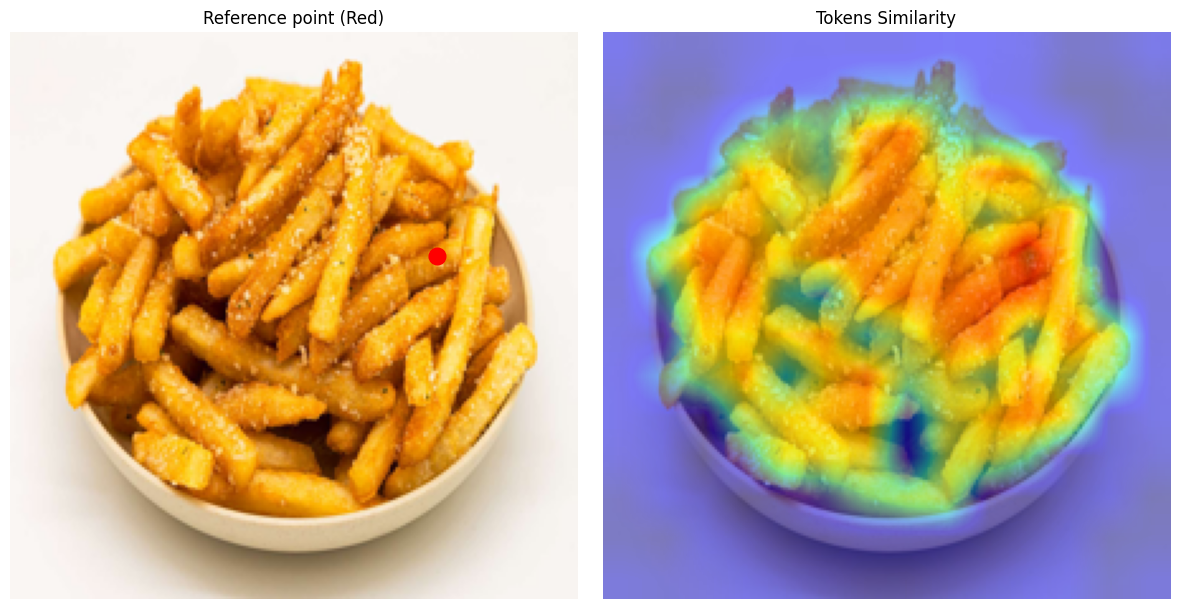

In [ ]:
# Attention-map 可视化

img_path = ("/root/autodl-tmp/123/fries.jpg")
test_image = Image.open(img_path).convert('RGB')
test_tensor = test_transform(test_image).unsqueeze(0).to(device)

# # 加载刚刚训练好的 ViT.pth
model = ViTBase(config).to(device)
model.load_state_dict(torch.load("ViT.pth", map_location=device))
model.eval()

with torch.no_grad():
    # Patch化 + CLS Token + Positional Embedding
    x = model.patch_embed(test_tensor).flatten(2).transpose(1, 2) # patch 化
    x = torch.cat((model.cls_token.expand(x.shape[0], -1, -1), x), dim=1) # 加 CLS Token
    x = x + model.pos_embed # 加 位置编码
    
    # 跑完全部12层ViT骨干网络
    for i in range(12):
        x = model.transformer.layers[i](x)
    
    # 提取除了CLS token以外的所有tokens (196个), 维度是 [196, 768]
    tokens = x[0, 1:, :] 
    
    # 预测结果
    logits = model.head(model.norm(x[:, 0]))
    pred_idx = logits.argmax(1).item()

# 图像的不同patches之间的语义相似度
ref_idx = 80
ref_token = tokens[ref_idx].unsqueeze(0)
sim = F.cosine_similarity(ref_token, tokens, dim=-1)
sim_map = sim.reshape(14, 14).cpu().numpy()
sim_heatmap = cv2.resize(sim_map, (224, 224))
# sim_heatmap = cv2.resize(sim_map, (224, 224), interpolation=cv2.INTER_NEAREST)
sim_heatmap = (sim_heatmap - sim_heatmap.min()) / (sim_heatmap.max() - sim_heatmap.min())
plt.figure(figsize=(12, 6))
display_img = np.array(test_image.resize((224, 224)))
plt.subplot(1, 2, 1)
plt.imshow(display_img)
y, x_coord = divmod(ref_idx, 14)
plt.plot(x_coord * 16 + 8, y * 16 + 8, 'ro', markersize=12)
plt.title(f"Reference point (Red)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(display_img)
plt.imshow(sim_heatmap, cmap='jet', alpha=0.5)
plt.title(f"Tokens Similarity")
plt.axis('off')
plt.tight_layout()
plt.show()